# Chapter 10 — Hypothesis Testing (Two Samples)

Comparing two means or two proportions, and why pairing helps.

| Section | What it covers |
|---|---|
| 10.1 | Comparing two means |
| 10.2 | Comparing two proportions |
| 10.3 | Paired samples |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Hypothesis Testing (Two Samples)](https://khh-aka-lucifer.github.io/statLab/chapters/two-sample-tests/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## Two groups, one question

Chapter 9 compared a sample against a fixed claim. Far more often you have two groups and want to
know whether the gap between them is bigger than chance alone would produce.

In [2]:
penguins = pd.read_csv(DATA / "penguins.csv")

adelie = penguins.loc[penguins["species"] == "Adelie", "body_mass_g"].dropna().to_numpy()
gentoo = penguins.loc[penguins["species"] == "Gentoo", "body_mass_g"].dropna().to_numpy()

for name, g in [("Adelie", adelie), ("Gentoo", gentoo)]:
    print(f"{name:10s} n = {len(g):3d}   mean = {g.mean():7.1f} g   sd = {g.std(ddof=1):6.1f} g")
print(f"\ndifference in means: {gentoo.mean() - adelie.mean():.1f} g")

Adelie     n = 151   mean =  3700.7 g   sd =  458.6 g
Gentoo     n = 123   mean =  5076.0 g   sd =  504.1 g

difference in means: 1375.4 g


## 10.1 Comparing two means

The **two-sample t-test** divides the observed difference by the noise you would expect in a
difference,

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{s_1^2/n_1 + s_2^2/n_2}}$$

This is **Welch's** version, which does not assume the two groups share a spread. Use it by default.
The older pooled-variance test needs equal variances and buys you almost nothing when they hold.

In [3]:
result = stats.ttest_ind(gentoo, adelie, equal_var=False)   # equal_var=False means Welch

print(f"t  = {result.statistic:.4f}")
print(f"df = {result.df:.2f}   <- fractional, which is the Welch correction at work")
print(f"p  = {result.pvalue:.3e}")

t  = 23.3860
df = 249.64   <- fractional, which is the Welch correction at work
p  = 7.710e-65


In [4]:
# by hand, so the formula is not a black box
se = np.sqrt(gentoo.var(ddof=1)/len(gentoo) + adelie.var(ddof=1)/len(adelie))
t_hand = (gentoo.mean() - adelie.mean()) / se

print(f"standard error of the difference = {se:.2f} g")
print(f"t by hand = {t_hand:.4f}")

# and a confidence interval for the difference, which is what you should actually report
lo = (gentoo.mean() - adelie.mean()) - stats.t.ppf(0.975, result.df) * se
hi = (gentoo.mean() - adelie.mean()) + stats.t.ppf(0.975, result.df) * se
print(f"95% CI for the difference: ({lo:.1f}, {hi:.1f}) g")

standard error of the difference = 58.81 g
t by hand = 23.3860
95% CI for the difference: (1259.5, 1491.2) g


A p-value of $8 \times 10^{-65}$ is not a close call. Gentoo penguins are heavier, by somewhere
between 1258 and 1493 grams, which is about 37 % of an Adelie. Here the effect is both certain and
large, which is the easy case.

The picture is worth drawing, because it shows what the test is reacting to.

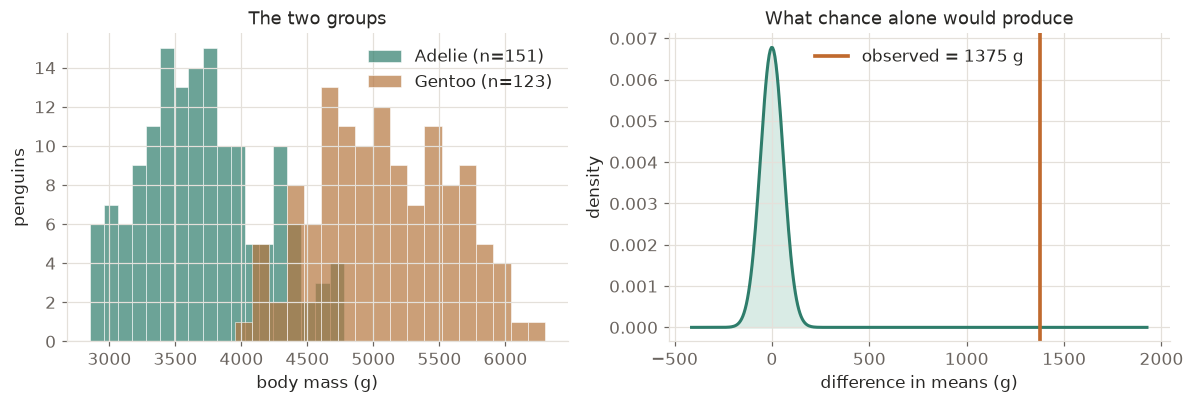

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

left.hist(adelie, bins=18, alpha=0.7, color=C["cat1"], label=f"Adelie (n={len(adelie)})",
          edgecolor="white", linewidth=0.5)
left.hist(gentoo, bins=18, alpha=0.7, color=C["cat2"], label=f"Gentoo (n={len(gentoo)})",
          edgecolor="white", linewidth=0.5)
left.set_xlabel("body mass (g)"); left.set_ylabel("penguins")
left.set_title("The two groups"); left.legend()

diff = gentoo.mean() - adelie.mean()
grid = np.linspace(-diff*0.3, diff*1.4, 400)
right.plot(grid, stats.norm.pdf(grid, 0, se), color=C["accent"], lw=2)
right.fill_between(grid, stats.norm.pdf(grid, 0, se), color=C["accent_soft"])
right.axvline(diff, color=C["warn"], lw=2.4, label=f"observed = {diff:.0f} g")
right.set_xlabel("difference in means (g)"); right.set_ylabel("density")
right.set_title("What chance alone would produce")
right.legend()

plt.tight_layout()
plt.show()

The right panel is the null hypothesis drawn. If the two species really had the same mean mass, the
difference we measure would land somewhere under that narrow curve. Our observed difference is off
the chart entirely, which is what a tiny p-value looks like.

In [ ]:
# Your turn.
# Compare Adelie against Chinstrap instead. Their means are much closer.
# 1. Run the Welch test and report t, p and the confidence interval.
# 2. Does the interval contain zero?
# 3. Now compare bill_length_mm for the same two species. Very different answer. Why?

chinstrap = penguins.loc[penguins["species"] == "Chinstrap", "body_mass_g"].dropna().to_numpy()
...

## 10.2 Comparing two proportions

For two proportions, the **two-proportion z-test** pools both samples into one overall rate and
judges the gap against the noise that rate implies.

The Titanic survival gap between women and men is the obvious case.

In [6]:
titanic = pd.read_csv(DATA / "titanic.csv")

women = titanic.loc[titanic["sex"] == "female", "survived"]
men   = titanic.loc[titanic["sex"] == "male", "survived"]

x1, n1 = women.sum(), len(women)
x2, n2 = men.sum(), len(men)
p1, p2 = x1/n1, x2/n2

print(f"women: {x1}/{n1} = {p1:.4f}")
print(f"men:   {x2}/{n2} = {p2:.4f}")
print(f"difference: {p1 - p2:.4f}")

women: 233/314 = 0.7420
men:   109/577 = 0.1889
difference: 0.5531


In [7]:
p_pool = (x1 + x2) / (n1 + n2)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z = (p1 - p2) / se_pool
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"pooled rate = {p_pool:.4f}")
print(f"SE          = {se_pool:.4f}")
print(f"z           = {z:.3f}")
print(f"p           = {p_value:.3e}")

# the interval uses the UNpooled standard error, which is a classic gotcha
se_unpooled = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
lo, hi = (p1-p2) - 1.96*se_unpooled, (p1-p2) + 1.96*se_unpooled
print(f"\n95% CI for the difference: ({lo:.4f}, {hi:.4f})")

pooled rate = 0.3838
SE          = 0.0341
z           = 16.219
p           = 0.000e+00

95% CI for the difference: (0.4951, 0.6111)


Note the two different standard errors. The **test** pools the two samples, because under $H_0$
there is only one rate and pooling estimates it best. The **interval** does not pool, because it is
not assuming the rates are equal. Using the wrong one is a common slip and scipy will not stop you.

Women were between 50 and 61 percentage points more likely to survive. That is an effect you can
describe to someone without using the word significant.

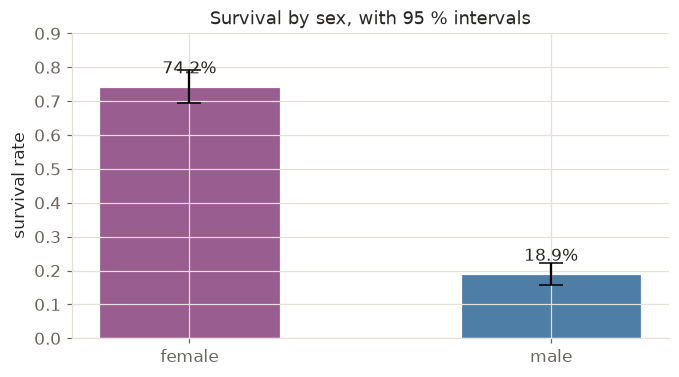

In [8]:
groups = ["female", "male"]
rates = [p1, p2]
errors = [1.96*np.sqrt(p*(1-p)/n) for p, n in [(p1, n1), (p2, n2)]]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(groups, rates, yerr=errors, capsize=8, width=0.5,
       color=[C["cat4"], C["cat3"]], edgecolor="white", linewidth=0.8)
for g, r in zip(groups, rates):
    ax.text(g, r + 0.04, f"{r:.1%}", ha="center", color=C["ink"])

ax.set_ylabel("survival rate"); ax.set_ylim(0, 0.9)
ax.set_title("Survival by sex, with 95 % intervals")
plt.show()

In [ ]:
# Your turn.
# Compare survival between First class and Third class passengers.
# 1. Compute both proportions and the pooled z-test.
# 2. Report the confidence interval for the difference, using the unpooled SE.
# 3. Which gap is larger, the sex gap or the class gap?

...

## 10.3 Paired samples

Sometimes the two groups are not separate groups at all. When each observation in one group is
naturally matched to one in the other, the data is **paired**, and treating it as independent throws
away the pairing and most of your power with it.

Gapminder gives us a perfect example. The same 142 countries, measured in 1952 and again in 2007.

In [9]:
gap = pd.read_csv(DATA / "gapminder.csv")
wide = gap[gap["year"].isin([1952, 2007])].pivot(index="country", columns="year", values="lifeExp").dropna()

print(f"{len(wide)} countries, measured twice each")
wide.head()

142 countries, measured twice each


year,1952,2007
country,,
Afghanistan,28.801,43.828
Albania,55.230,76.423
Algeria,43.077,72.301
Angola,30.015,42.731
Argentina,62.485,75.320


In [10]:
before, after = wide[1952].to_numpy(), wide[2007].to_numpy()
gain = after - before

paired = stats.ttest_rel(after, before)
naive = stats.ttest_ind(after, before, equal_var=False)

print(f"mean gain: {gain.mean():.2f} years (sd of the gains {gain.std(ddof=1):.2f})")
print()
print(f"paired t-test      t = {paired.statistic:7.2f}   p = {paired.pvalue:.2e}")
print(f"independent t-test t = {naive.statistic:7.2f}   p = {naive.pvalue:.2e}")

mean gain: 17.95 years (sd of the gains 8.12)

paired t-test      t =   26.33   p = 2.75e-56
independent t-test t =   12.45   p = 1.21e-28


Same data, same question, and the paired test gives a $t$ twice as large. Nothing was cheated. The
paired test simply knows something the other one does not.

Countries differ enormously from each other, and all of that between-country variation sits in the
denominator of the independent test as if it were noise. The paired test subtracts each country from
itself first, so that variation cancels, and only the spread of the *changes* remains.

In [11]:
print(f"spread between countries (1952): {before.std(ddof=1):.2f} years")
print(f"spread of the changes:           {gain.std(ddof=1):.2f} years")
print("\nThe paired test only has to fight the second number.")

spread between countries (1952): 12.23 years
spread of the changes:           8.12 years

The paired test only has to fight the second number.


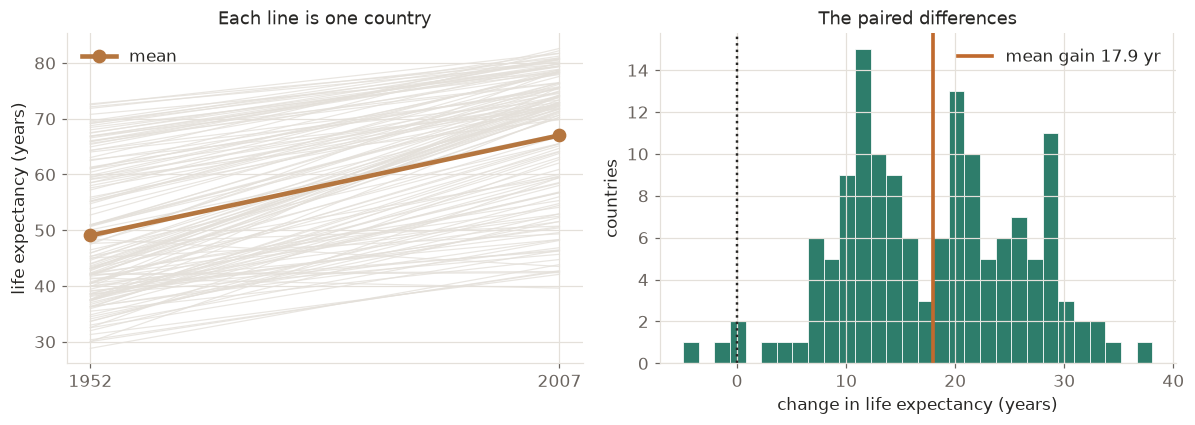

In [12]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

for b, a in zip(before, after):
    left.plot([0, 1], [b, a], color=C["line"], lw=0.8, alpha=0.8)
left.plot([0, 1], [before.mean(), after.mean()], color=C["cat2"], lw=3, marker="o", ms=8,
          label="mean")
left.set_xticks([0, 1]); left.set_xticklabels(["1952", "2007"])
left.set_ylabel("life expectancy (years)")
left.set_title("Each line is one country"); left.legend()

right.hist(gain, bins=30, color=C["accent"], edgecolor="white", linewidth=0.5)
right.axvline(0, color=C["ink"], lw=1.6, ls=":")
right.axvline(gain.mean(), color=C["warn"], lw=2.4, label=f"mean gain {gain.mean():.1f} yr")
right.set_xlabel("change in life expectancy (years)"); right.set_ylabel("countries")
right.set_title("The paired differences"); right.legend()

plt.tight_layout()
plt.show()

The left panel is why pairing works. The lines start at wildly different heights and almost all of
them slope up. The height is irrelevant to the question, and pairing removes it.

Now look at the right panel and find the two bars below zero.

In [13]:
worse = wide[gain < 0]
print("Countries where life expectancy FELL between 1952 and 2007:")
for country, row in worse.iterrows():
    print(f"  {country:12s} {row[1952]:.1f} -> {row[2007]:.1f} years  ({row[2007]-row[1952]:+.1f})")

Countries where life expectancy FELL between 1952 and 2007:
  Swaziland    41.4 -> 39.6 years  (-1.8)
  Zimbabwe     48.5 -> 43.5 years  (-5.0)


Two countries out of 142, both in southern Africa, both devastated by the HIV/AIDS epidemic. A mean
gain of 18 years is the headline and it is true, and those two rows are also true. Reporting the
average without ever looking at the tails is how statistics earns its bad reputation.

In [ ]:
# Your turn.
# Redo the paired analysis for gdpPercap instead of lifeExp, comparing 1952 with 2007.
# 1. How many countries got poorer?
# 2. Is the paired test still much stronger than the independent one?
# 3. GDP is very skewed. Try the test on log10(gdpPercap) instead and see what changes.

...

## Exercises

1. **When pairing does not help.** Pair each country with a *randomly chosen different* country
   rather than with itself, and rerun the paired test. The advantage should vanish. That is the proof
   that the gain came from the matching, not from the arithmetic.

2. **Equal variances.** Run the Adelie against Gentoo comparison with `equal_var=True` and compare.
   Then check whether the equal-variance assumption is reasonable, using `stats.levene`. Does the
   conclusion change?

3. **The sign test.** Ignore the size of each country's change and count only how many went up.
   Test that count against a binomial with $p = 0.5$. You lose power by throwing away magnitudes.
   How much?

4. **Multiple comparisons.** Run Welch tests on all three pairs of penguin species for all four
   measurements, which is twelve tests. At $\alpha = 0.05$ you would expect about one false alarm by
   chance. Look up the Bonferroni correction and apply it.

5. **Power by simulation.** For the Adelie against Chinstrap mass comparison, estimate the power of
   the test at the observed effect size by resampling. How many penguins per species would you need
   for 80 % power?

## What you should take away

Comparing two means means dividing the observed gap by the noise expected in a gap, and Welch's
version is the safe default because it does not assume matched spreads.

For proportions, the test pools and the interval does not, which trips people up regularly.

And when observations come in natural pairs, pairing removes the between-subject variation from the
denominator. The gapminder data showed that doubling the t statistic with no extra data at all,
purely by respecting the structure that was already there.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*